# Example of how to use the adaptive decomposition

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from pathlib import Path

from adapt_decomp.loaders import load_example, load_neuromotion
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.plots import plot_sep_vectors_diff, plot_whitening_comp, plot_sep_vectors_comp
from adapt_decomp.utils import rate_of_agreement_paired, rate_of_agreement, get_coefficient_of_variation, get_discharge_rate, get_pulse_to_noise_ratio, get_silhouette_measure, find_reliable_units
from adapt_decomp.io import load_output

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)

## 1. Input data
The `AdaptDecomp` module requires:
- An EMG dataset
- Precalibrated decomposition model based on static conditions including
    - EMG during calibration
    - extension factor
    - whitening 
    - separation vectors
    - spike/baseline centroids
    - outputted IPTs
    - outputted spikes

The code uses the EMG during calibration and outputted spikes and IPTs to compute the covariance matrix of the whitenined EMG signals during calibration and the mean values of the contrast function (logcosh, cube) of the sources during calibration to calculate the whitening and separation losses (median squared error between the KL-divergence and estimated kurtosis of the adaptation and calibration conditions).
    
This notebook applies the decomposition adaptation to a wrist dynamic contraction simulated with [NeuroMotion](https://github.com/shihan-ma/NeuroMotion). The EMG signals were simulated from the forearm (band of 10 rows and 32 columns) during an index flexion (FDS muscle activated at 15% MVC) while the wrist flexed from 0 degrees to -40 degrees in a staircase pattern (30 s plateaus, 10 s ramps at 1deg/s). The first plateau is used to precalibrate a convolutive blind source separation model that is adapted for the rest of the contraction.

Load the simulated dataset and the corresponding decomposition during the calibration segment.

In [2]:
# Load data
path_emg = Path('..', 'data', 'example', 'data_sim.hdf5')
path_decomp = Path('..', 'data', 'example', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)
print(data.keys())

dict_keys(['emg', 'timestamps', 'fs', 'force_profile', 'angle_profile', 'ch_map', 'whitening', 'sep_vectors', 'base_centr', 'spikes_centr', 'ext_fact', 'emg_calib', 'ipts_calib', 'spikes_calib', 'spikes_gt', 'preprocess'])


Take a look at the data

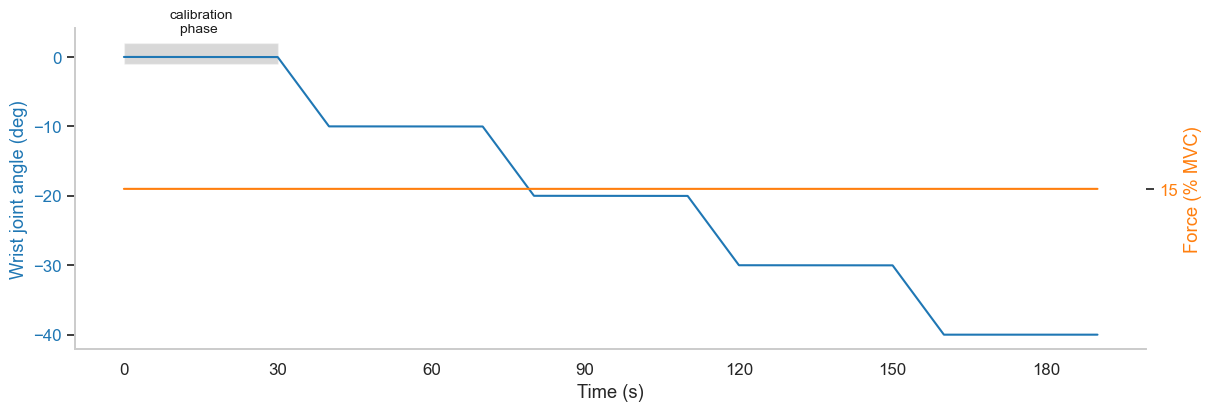

In [3]:
fig, axs = plt.subplots(1,1, figsize=(12,4), layout='constrained')

axs.add_patch( Rectangle((0,-1), 30, 3, facecolor='grey', edgecolor=None, alpha=0.3) )
axs.text(15, 5, 'calibration\nphase ', dict(ha='center', va='center', fontsize=10, color='k'))
axs.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
axs.tick_params(axis='y', labelcolor='tab:blue')
axs.set_ylabel('Wrist joint angle (deg)', color='tab:blue')
axs.set_xlabel('Time (s)')
axs.grid(False)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

axs1 = axs.twinx()
axs1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
axs1.tick_params(axis='y', labelcolor='tab:orange')
axs1.set_ylabel('Force (% MVC)', color='tab:orange')
axs1.spines['top'].set_visible(False)
axs1.spines['right'].set_visible(False)
axs1.set(xticks=range(0,191,30), yticks=[15])
axs1.grid(False)

plt.show()

## 2. Decomposition comparison for online execution

For real-time applications the computation of the loss can be avoided and the saving of the adapted parameters can be switched off for maximum efficiency. The loss is only needed to optimise the hyperparameters of the decomposition (whitening and separation vectors learning rate), but it is not used during the adaptation. This settings can be modified for more in depth analysis as it is shown in the next section.

### 2.1. Without adaptation

In [4]:
# Define configuration
config = Config()
# Override needed parameters
config.ext_fact = data['ext_fact']
config.adapt_wh = False     # Deactivate whitening adapataion
config.adapt_sv = False     # Deactivate separation vector adaptation
config.adapt_sd = False     # Deactivate spike detection adaptation
config.compute_loss = True  # For faster execution, set to False
config.device = 'cpu'
config.contrast_scope = 'spike_based'


# Run decomposition
dyndec_no_adapt = AdaptDecomp(
    emg = data['emg'].clone(),
    whitening = data['whitening'].clone(),
    sep_vectors = data['sep_vectors'].clone(),
    base_centr = data['base_centr'].clone(),
    spikes_centr = data['spikes_centr'].clone(),
    emg_calib = data['emg_calib'].clone(),
    ipts_calib = data['ipts_calib'].clone(),
    spikes_calib = data['spikes_calib'].clone(),
    preprocess = data['preprocess'],
    config = config
    )
outputs_no_adapt = dyndec_no_adapt.run()

print('Decomposition without adaptation done!')

Decomposition without adaptation done!


### 2.2 With adaptation

### 2.3. Evaluate execution time per batch and method

In [27]:
# CPU with loss calculaion
title = 'No adaptation'
print(title + '\n' + '-'*len(title))
for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
    if key != 'method':
        print(f'{key:>15}: {outputs_no_adapt[key].mean():.3f} ± {outputs_no_adapt[key].std():.3f} ms')

title = 'Adaptation'
print('\n' + title + '\n' + '-'*len(title))
for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
    if key != 'method':
        print(f'{key:>15}: {outputs_adapt[key].mean():.3f} ± {outputs_adapt[key].std():.3f} ms')

No adaptation
-------------
     wh_time_ms: 10.411 ± 1.591 ms
     sv_time_ms: 0.076 ± 0.028 ms
     sd_time_ms: 0.620 ± 0.309 ms
  total_time_ms: 11.107 ± 1.657 ms

Adaptation
----------
     wh_time_ms: 12.426 ± 0.995 ms
     sv_time_ms: 0.539 ± 0.205 ms
     sd_time_ms: 0.491 ± 0.166 ms
  total_time_ms: 13.456 ± 1.090 ms


## 4. Evaluate the adaptation effect
To evaluate the effect of the adaptation we can take a look at the whitening and separation vector losses, defined as the median squared error between the Kulback-Leibler divergence of the whitened covariance during calibration and adaptation, and the median squared error between the contrast functions during the calibration and the adaptation, respectively.

Note how without adaptation the whitening loss increases following the same trend as the deviation in wrist joint angle, and how most of the spikes are lost after 10 degrees.

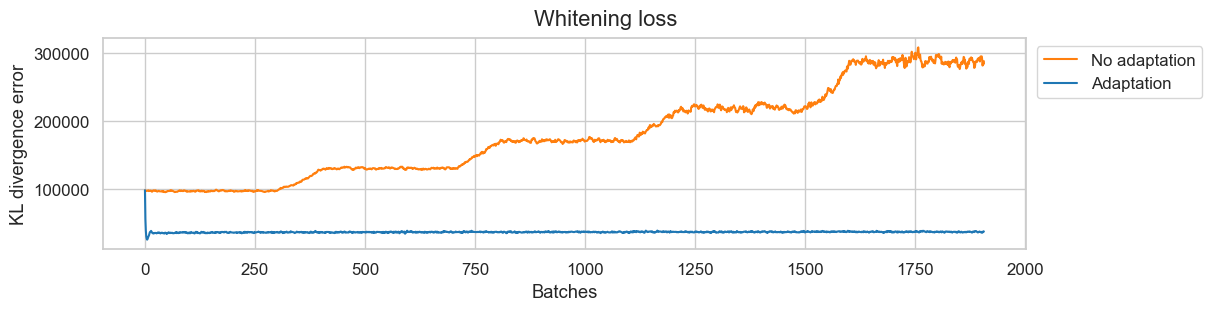

In [28]:
colors = ['tab:orange', 'tab:blue']

# Check the KL divergence error
fig, axs = plt.subplots(1, 1, figsize=(12, 3), layout='constrained')
axs.plot(outputs_no_adapt['wh_loss'][:-1], label='No adaptation', color=colors[0])
axs.plot(outputs_adapt['wh_loss'][:-1], label='Adaptation', color=colors[1])
axs.set(xlabel='Batches', ylabel='KL divergence error')
axs.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.suptitle('Whitening loss')
plt.show()

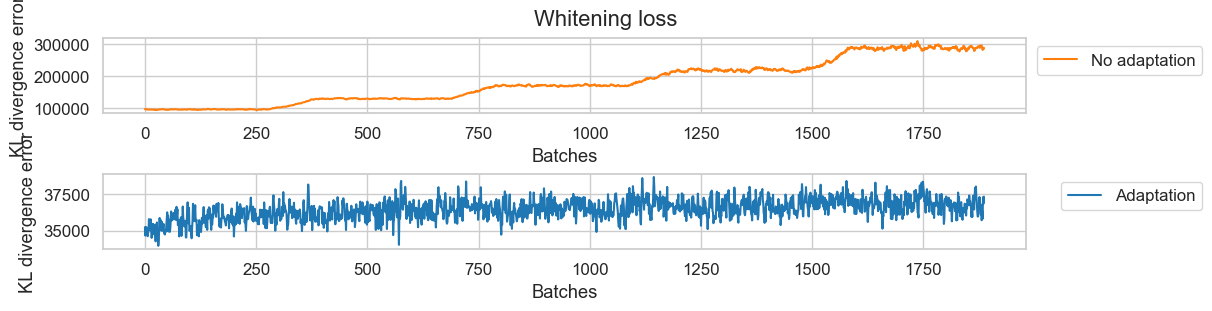

In [29]:
colors = ['tab:orange', 'tab:blue']

# Check the KL divergence error
fig, axs = plt.subplots(2, 1, figsize=(12, 3), layout='constrained')

axs[0].plot(outputs_no_adapt['wh_loss'][20:-1], label='No adaptation', color=colors[0])
axs[0].set(xlabel='Batches', ylabel='KL divergence error')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

axs[1].plot(outputs_adapt['wh_loss'][20:-1], label='Adaptation', color=colors[1])
axs[1].set(xlabel='Batches', ylabel='KL divergence error')
axs[1].legend(loc='upper right', bbox_to_anchor=(1.2, 1))


plt.suptitle('Whitening loss')
plt.show()

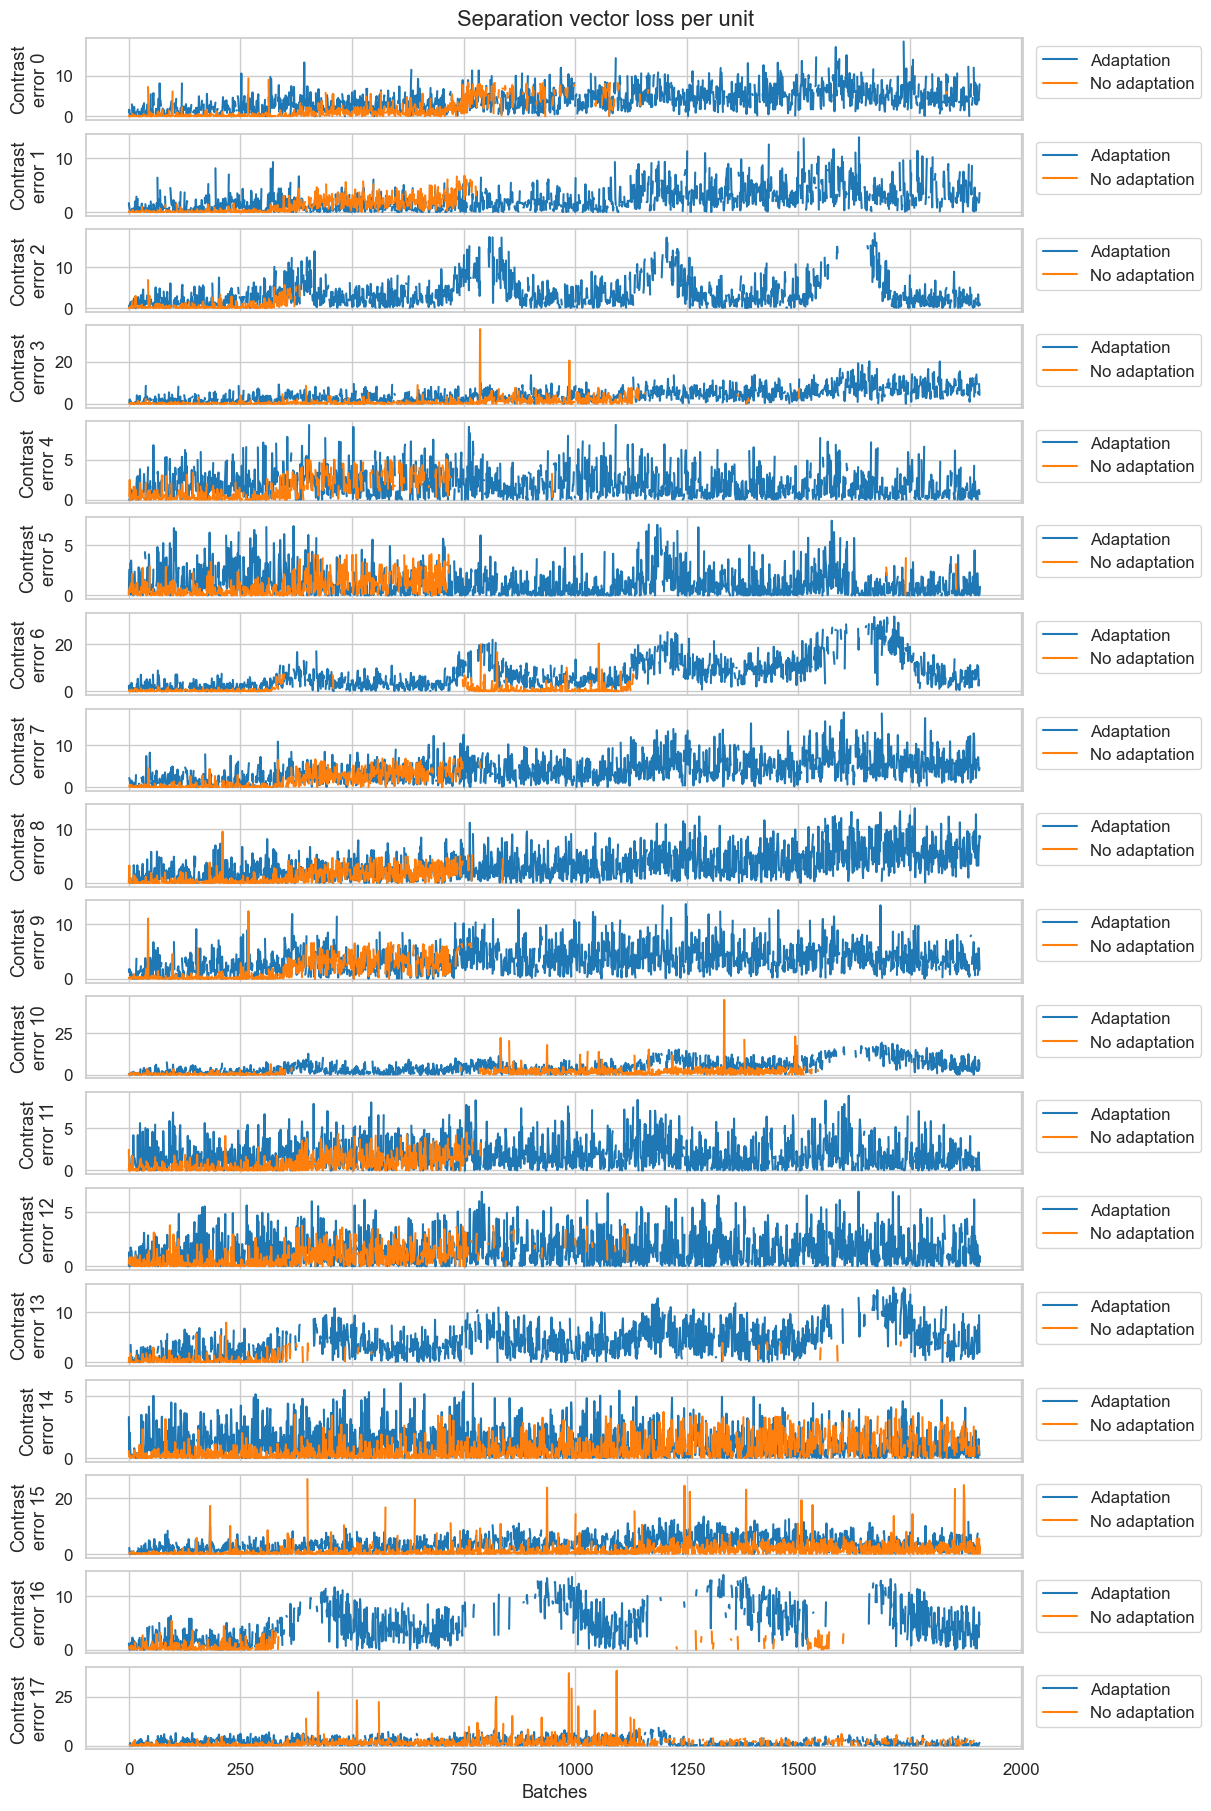

In [30]:
units = len(data['spikes_centr'])
fig, axs = plt.subplots(units, 1, figsize=(12, units), layout='constrained', sharex=True)

for unit in range(units):
    axs[unit].plot(outputs_adapt['sv_loss'][:,unit], label='Adaptation', color=colors[1])
    axs[unit].plot(outputs_no_adapt['sv_loss'][:,unit], label='No adaptation', color=colors[0])
    axs[unit].set(ylabel=f'Contrast\nerror {unit}')
    axs[unit].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    if unit == units-1:
        axs[unit].set(xlabel='Batches')

plt.suptitle('Separation vector loss per unit') 
plt.show()

## 5. Plot IPTs and spikes

Now let's plot the spike trains at the maximum angle deviation with and without adaptation. Notice how adaptation recovers almost all of the spikes that were lost with the change in joint angle.

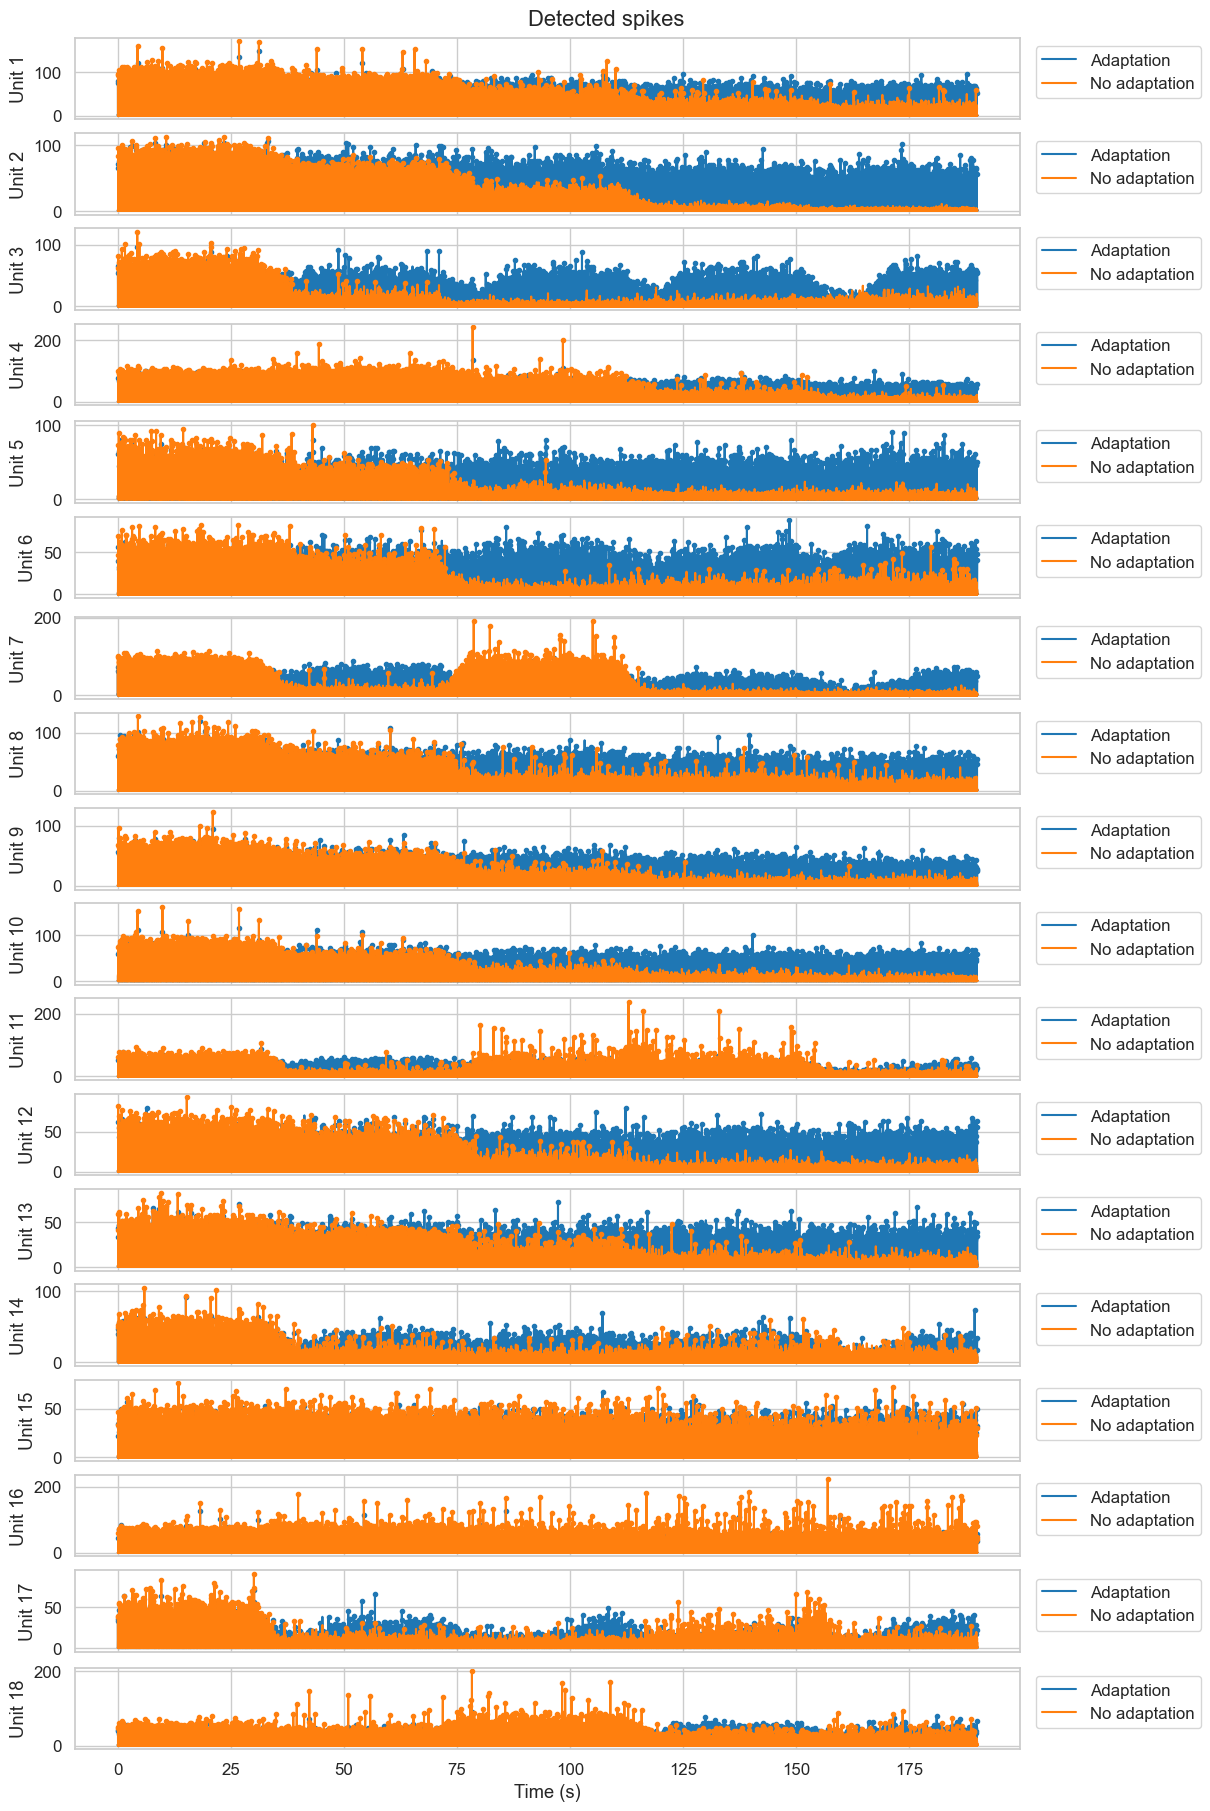

In [31]:
units = len(data['spikes_centr'])
# time_window = [0, 10] # First iso
# time_window = [180, 190] # Final iso
# time_window = [30, 40] # First ramp
# time_window = [40, 70] # Second iso

time_window = [0, 190] # All

idxs = np.arange(time_window[0]*2048, time_window[1]*2048).astype(int)
plot_ipts = True

fig, axs = plt.subplots(units, 1, figsize=(12, units), layout='constrained', sharex=True)

for unit in range(units):
    if plot_ipts:
        axs[unit].plot(data['timestamps'][idxs], outputs_adapt['ipts'][idxs,unit] ** 2, label='Adaptation', color=colors[1])
    spikes_times = data['timestamps'][idxs][outputs_adapt['spikes'][idxs, unit].to(dtype=bool)]
    spikes_height = outputs_adapt['ipts'][idxs, unit][outputs_adapt['spikes'][idxs, unit].to(dtype=bool)] ** 2
    axs[unit].plot(spikes_times, spikes_height, linestyle='None', marker='.', color=colors[1])
    
    if plot_ipts:
        axs[unit].plot(data['timestamps'][idxs], outputs_no_adapt['ipts'][idxs,unit] ** 2, label='No adaptation', color=colors[0])
    spikes_times = data['timestamps'][idxs][outputs_no_adapt['spikes'][idxs, unit].to(dtype=bool)]
    spikes_height = outputs_no_adapt['ipts'][idxs, unit][outputs_no_adapt['spikes'][idxs, unit].to(dtype=bool)] ** 2
    axs[unit].plot(spikes_times, spikes_height, linestyle='None', marker='.', color=colors[0])

    axs[unit].set(ylabel=f'Unit {unit+1}') 
    if plot_ipts:
        axs[unit].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    if unit == units-1:
        axs[unit].set(xlabel='Time (s)')

plt.suptitle('Detected spikes')
plt.show()


### 5.1. Decomposition quality metrics

Compare silhouette measure (SIL), pulse-to-noise ratio (PNR), mean discharge rate (DR), and
coefficient of variation of inter-spike intervals (CoV) between the no-adaptation and adaptation
conditions across all motor units.

A unit is considered **good** if its SIL exceeds 0.9 (Holobar et al. 2014).
Results are stored in a tidy pandas DataFrame for easy downstream analysis.

In [32]:
import pandas as pd

timestamps_np = data['timestamps'].numpy()
ext_fact      = data['ext_fact']

conditions = {
    'No adaptation': outputs_no_adapt,
    'Adaptation':    outputs_adapt,
}

rows = []
for label, outputs in conditions.items():
    spikes_np = outputs['spikes'].numpy().astype(float)
    ipts_np   = outputs['ipts'].numpy()

    sil = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr  = get_discharge_rate(spikes_np, timestamps_np, discard_isi=None)
    cov = get_coefficient_of_variation(spikes_np, timestamps_np, discard_isi=None)
    good = find_reliable_units(
        dr, cov, sil, pnr,
        dr_low_thr=5,
        dr_upp_thr=35,
        cov_thr=0.35,
        sil_thr=0.9,
        pnr_thr=30,
    )

    for u in range(spikes_np.shape[1]):
        rows.append({
            'unit':      u,
            'good':      good[u],
            'condition': label,
            'SIL':       sil[u],
            'PNR (dB)':  pnr[u],
            'DR (pps)':  dr[u],
            'CoV (%)':   cov[u],
        })

df_metrics = pd.DataFrame(rows)
n_total = df_metrics['unit'].nunique()

print(df_metrics.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']].agg(['median', 'mean']).round(2))
print()
for cond, grp in df_metrics.groupby('condition'):
    n_good = grp['good'].sum()
    print(f'{cond}: {n_good} / {n_total} good units')


                 SIL       PNR (dB)        DR (pps)       CoV (%)      
              median  mean   median   mean   median  mean  median  mean
condition                                                              
Adaptation      0.95  0.93    33.03  32.96     8.86  8.95    0.24  0.35
No adaptation   0.94  0.93    31.78  32.16     5.41  5.91    3.17  3.21

Adaptation: 12 / 18 good units
No adaptation: 0 / 18 good units


In [33]:
cond_map = {'No adaptation': 'no_adapt', 'Adaptation': 'adapt'}

df_metrics['condition'] = pd.Categorical(
    df_metrics['condition'], categories=['No adaptation', 'Adaptation'], ordered=True
)
df_metrics_comp = df_metrics.pivot(
    index='unit',
    columns='condition',
    values=['good', 'SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)'],
)
df_metrics_comp.columns = [
    f"{metric}_{cond_map[cond]}" for metric, cond in df_metrics_comp.columns
]
df_metrics_comp = df_metrics_comp.reset_index()
display(df_metrics_comp)

,unit,good_no_adapt,good_adapt,SIL_no_adapt,SIL_adapt,PNR (dB)_no_adapt,PNR (dB)_adapt,DR (pps)_no_adapt,DR (pps)_adapt,CoV (%)_no_adapt,CoV (%)_adapt
0,0,False,True,0.948005,0.964647,35.95314,39.232531,4.539991,8.674507,3.208029,0.209712
1,1,False,True,0.962365,0.96298,41.392679,38.648009,5.940503,8.04294,3.027141,0.209949
2,2,False,False,0.960965,0.930836,35.044174,32.911711,4.700842,7.786352,3.113627,0.597533
3,3,False,True,0.953939,0.952257,35.219719,36.890152,5.388897,8.304746,4.32531,0.22146
4,4,False,True,0.931819,0.951168,32.072399,33.169932,5.438367,8.092488,4.809108,0.229249
5,5,False,True,0.93363,0.947113,28.948402,33.146181,3.659407,9.604023,5.08568,0.225187
6,6,False,False,0.956723,0.896505,36.269634,34.350865,5.459641,8.180608,4.143151,0.561396
7,7,False,True,0.943961,0.954144,34.263332,36.579902,3.947356,9.076352,3.309818,0.226531
8,8,False,True,0.944438,0.937677,33.107858,33.276401,5.038404,10.705062,6.855704,0.226261
9,9,False,True,0.933673,0.96049,35.886478,35.943515,5.882109,9.080218,2.998582,0.218466


/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_7566/1395949304.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_7566/1395949304.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_7566/1395949304.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/qk/042lzxjj5nzgzp_z1s9jc9dr0000gn/T/ipykernel_7566/1395949304.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

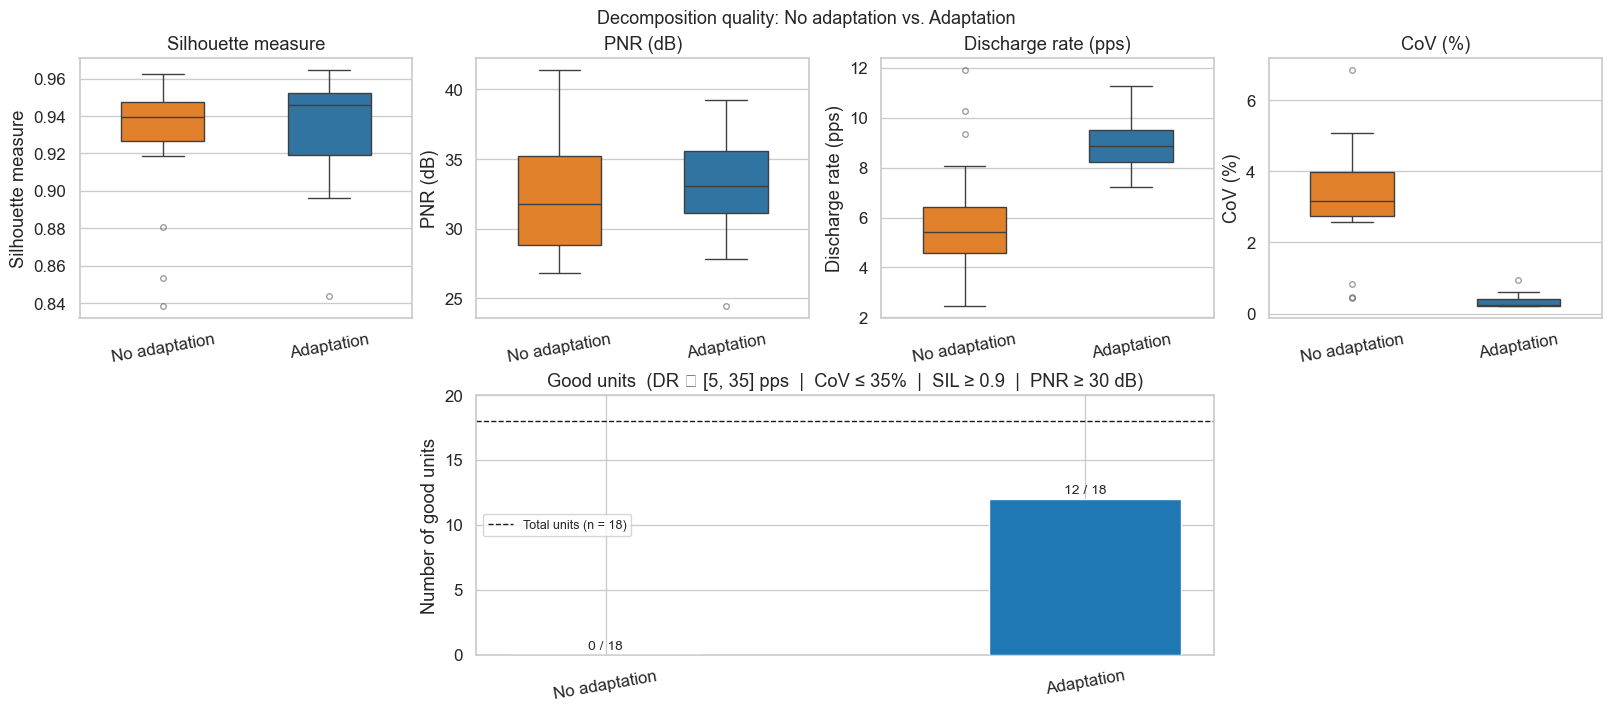

In [34]:
palette = {'No adaptation': 'tab:orange', 'Adaptation': 'tab:blue'}
order   = ['No adaptation', 'Adaptation']

fig = plt.figure(figsize=(16, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)

ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])   # centred in the second row

# --- Boxplots ---
for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(
        data=df_metrics, x='condition', y=col,
        order=order, palette=palette, width=0.5,
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        ax=ax,
    )
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=10)

# --- Good units barplot ---
good_counts = df_metrics.groupby('condition')['good'].sum().reindex(order)

bars = ax_bar.bar(
    order, good_counts.values,
    color=[palette[c] for c in order],
    width=0.4, zorder=3,
)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(
    ylabel='Number of good units',
    title='Good units  (DR ∈ [5, 35] pps  |  CoV ≤ 35%  |  SIL ≥ 0.9  |  PNR ≥ 30 dB)',
    ylim=(0, n_total + 2),
)
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=10)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        count + 0.2,
        f'{int(count)} / {n_total}',
        ha='center', va='bottom', fontsize=10,
    )

plt.suptitle('Decomposition quality: No adaptation vs. Adaptation', fontsize=13)
plt.show()


## 6. Compute rate of agreement with ground truth
Since the dataset is simulated we can compute the rate of agreement between the ground truth and the detected spikes. To match the detected to the simulated ones we will use the calibration segment data (first 30s) only.

In [35]:
# Compute rate of agreement over the calibration phase only
idxs = np.arange(0, 30 * 2048).astype(int)

roa_no_adapt, pair_no_adapt, lag_no_adapt = rate_of_agreement(data['spikes_gt'].numpy()[idxs], outputs_no_adapt['spikes'].numpy()[idxs], fs=data['fs'])
roa_adapt, pair_adapt, lag_adapt = rate_of_agreement(data['spikes_gt'].numpy()[idxs], outputs_adapt['spikes'].numpy()[idxs], fs=data['fs'])

print(f'Rate of agreement (no adaptation): {roa_no_adapt.mean()*100:.2f} ± {roa_no_adapt.std()*100:.2f} (med: {np.median(roa_no_adapt)*100:.2f}) %')
print(f'Rate of agreement (adaptation): {roa_adapt.mean()*100:.2f} ± {roa_adapt.std()*100:.2f} (med: {np.median(roa_adapt)*100:.2f}) %')

# Make sure the pairs are the same
pair_adapt_array = np.array(pair_adapt)
pair_no_adapt_array = np.array(pair_no_adapt)
print(f'Same matched units: {np.all(pair_no_adapt_array[:, 0] == pair_adapt_array[:, 0])}')

Rate of agreement (no adaptation): 99.40 ± 0.49 (med: 99.35) %
Rate of agreement (adaptation): 97.82 ± 2.03 (med: 98.48) %
Same matched units: True


Now let's compute the rate of agreement for the detected spikes over the whole recording.

Rate of agreement (no adaptation): 37.88 ± 18.23 (med: 37.29) %
Rate of agreement (adaptation): 88.25 ± 22.00 (med: 98.19) %


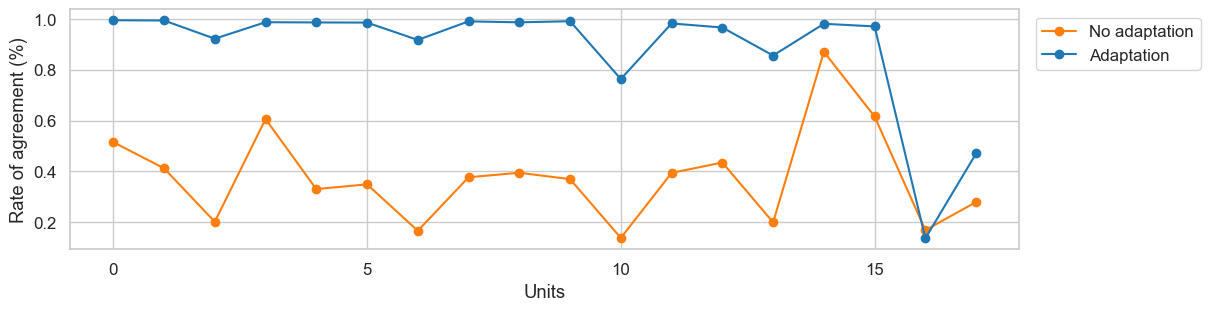

In [36]:
# Get simulated spikes
sim_spikes = data['spikes_gt'].numpy()[:, pair_no_adapt_array[:, 0]]

# Compute rate of agreement
roa_no_adapt, pair_no_adapt, lag_no_adapt = rate_of_agreement_paired(sim_spikes, outputs_no_adapt['spikes'].numpy(), fs=data['fs'], tol_spike_ms=2)
roa_adapt, pair_adapt, lag_adapt = rate_of_agreement_paired(sim_spikes, outputs_adapt['spikes'].numpy(), fs=data['fs'], tol_spike_ms=2)

print(f'Rate of agreement (no adaptation): {roa_no_adapt.mean()*100:.2f} ± {roa_no_adapt.std()*100:.2f} (med: {np.median(roa_no_adapt)*100:.2f}) %')
print(f'Rate of agreement (adaptation): {roa_adapt.mean()*100:.2f} ± {roa_adapt.std()*100:.2f} (med: {np.median(roa_adapt)*100:.2f}) %')

# Plot results
colors = ['tab:orange', 'tab:blue']
fig, axs = plt.subplots(1, 1, figsize=(12, 3), layout='constrained')
axs.plot(roa_no_adapt, marker='o', label='No adaptation', color=colors[0])
axs.plot(roa_adapt, marker='o', label='Adaptation', color=colors[1])
axs.set(xlabel='Units', ylabel='Rate of agreement (%)', xticks=range(0, units,5))
axs.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

## 7. Implementation diagnostics (debug mode)

This section shows per-batch internal quantities exposed by the new backend algorithm when `debug=True`.
Each quantity maps directly to a term in the adaptation equations, making it easy to verify correctness
and tune hyperparameters.

**Overview of diagnostics:**

| Group | Quantity | What it measures |
|---|---|---|
| Whitening | `K`, `K_cal` | Online vs calibration KL-like contrast of whitened covariance |
| Whitening | `whitening_error` | Raw KL error `K − K_cal` (drives the V update directly) |
| Whitening | `delta_V_norm` | Frobenius norm of V update (trust-region clipped to `max_rel_delta_v × ‖V‖`) |
| Whitening | `Rz_trace`, `Rz_logdet` | Raw FIFO covariance statistics |
| Source | `kappa`, `kappa_cal` | Online vs calibration log-cosh contrast per unit |
| Source | `contrast_error` | Raw contrast error `κ − κ_cal` per unit (drives the B update directly) |
| Source | `spike_counts` | Detected spikes per unit per batch (gates the B update) |
| Source | `active` | Whether each unit's B row was actually updated this batch |
| Source | `delta_B_norm` | Row-wise norm of B update (trust-region clipped to `max_rel_delta_b × ‖b_j‖`) |
| Source | `orthogonality_error` | ‖BB^T − I‖_F after QR orthonormalization |
| Centroids | `spike_centroid`, `base_centroid` | Adaptive detection thresholds (online EMA) |
| Centroids | `spike_centroid_cal`, `base_centroid_cal` | Immutable calibration references |
| Centroids | `centroid_drift` | Mean absolute drift of spike centroid from calibration value |
| Peaks | `peak_counts_before/after` | NMS candidates vs accepted spikes per unit per batch |

In [37]:
import torch

def _val(d, key):
    v = d.get(key)
    if v is None:
        return float('nan')
    if isinstance(v, torch.Tensor):
        return v.detach().cpu().numpy()
    return v

batches  = sorted(diag.keys())
n_batches = len(batches)
n_units   = len(data['spikes_centr'])

# --- Whitening ---
K            = np.array([_val(diag[b], 'K')              for b in batches], dtype=float)
K_cal_val    = float(np.atleast_1d(_val(diag[batches[0]], 'K_cal'))[0])
wh_error     = np.array([_val(diag[b], 'whitening_error') for b in batches], dtype=float)
delta_V_norm = np.array([_val(diag[b], 'delta_V_norm')    for b in batches], dtype=float)
Rz_trace     = np.array([_val(diag[b], 'Rz_trace')        for b in batches], dtype=float)
Rz_logdet    = np.array([_val(diag[b], 'Rz_logdet')       for b in batches], dtype=float)

# --- Source contrast [n_batches, n_units] ---
def _stack(key):
    rows = []
    for b in batches:
        v = _val(diag[b], key)
        rows.append(np.atleast_1d(v) if not isinstance(v, float) else np.full(n_units, v))
    return np.stack(rows)

kappa          = _stack('kappa')
kappa_cal_arr  = np.atleast_1d(_val(diag[batches[0]], 'kappa_cal'))
contrast_error = _stack('contrast_error')
spike_counts   = _stack('spike_counts')
active         = _stack('active').astype(float)
delta_B_norm   = _stack('delta_B_norm')
orth_error     = np.array([float(np.atleast_1d(_val(diag[b], 'orthogonality_error'))[0])
                            for b in batches])

# --- Centroids [n_batches, n_units] ---
spike_centroid         = _stack('spike_centroid')
base_centroid          = _stack('base_centroid')
spike_centroid_cal_arr = np.atleast_1d(_val(diag[batches[0]], 'spike_centroid_cal'))
base_centroid_cal_arr  = np.atleast_1d(_val(diag[batches[0]], 'base_centroid_cal'))
centroid_drift         = np.array([float(np.atleast_1d(_val(diag[b], 'centroid_drift'))[0])
                                    for b in batches])

# --- Peak counts [n_batches, n_units] ---
peaks_before = _stack('peak_counts_before')
peaks_after  = _stack('peak_counts_after')

print(f'K_cal = {K_cal_val:.4f}')
print(f'kappa_cal = {kappa_cal_arr}')
print('Arrays ready.')

K_cal = 0.0000
kappa_cal = [9.31567   8.659442  7.6932383 8.899928  7.1800404 6.5916867 8.652225
 8.526312  7.307132  8.306389  7.0504274 6.8287883 6.2013416 6.535212
 5.8386188 7.5028405 6.113971  6.1836414]
Arrays ready.


### 7.1 Whitening diagnostics

The whitening matrix **V** is updated via a natural-gradient step with trust-region clipping:

$$\Delta V = -e_v \,(R_z - I)\,V, \qquad \|\Delta V\|_F \leq \texttt{max\_rel\_delta\_v} \times \|V\|_F$$

$R_z$ is the regularised whitened covariance estimated from the extended-EMG FIFO (always full-rank),
and $e_v = K - K_{\text{cal}}$ is the raw KL-like error.
$K_{\text{cal}}$ is an immutable scalar computed once from the full calibration dataset.
The trust region `max_rel_delta_v` is the sole rate control: when the error is large the clip activates
and V moves at the maximum allowed rate; when the error is small the unclipped step shrinks proportionally.

**How to read the plots:**
- **K vs K_cal** — K measures how far the whitened covariance is from the identity.
  Values above K_cal signal that the signal has drifted; the algorithm then pushes V to restore whiteness.
- **Whitening error e_v = K − K_cal** — raw error driving the update. Near-zero = stationary;
  large positive = growing covariance mismatch.
- **‖ΔV‖_F** — bounded by `max_rel_delta_v × ‖V‖_F`. Proportional to the error when small;
  pinned at the ceiling when large.
- **Rz trace and logdet** — trace ≈ D and logdet ≈ 0 for a near-identity whitened covariance.

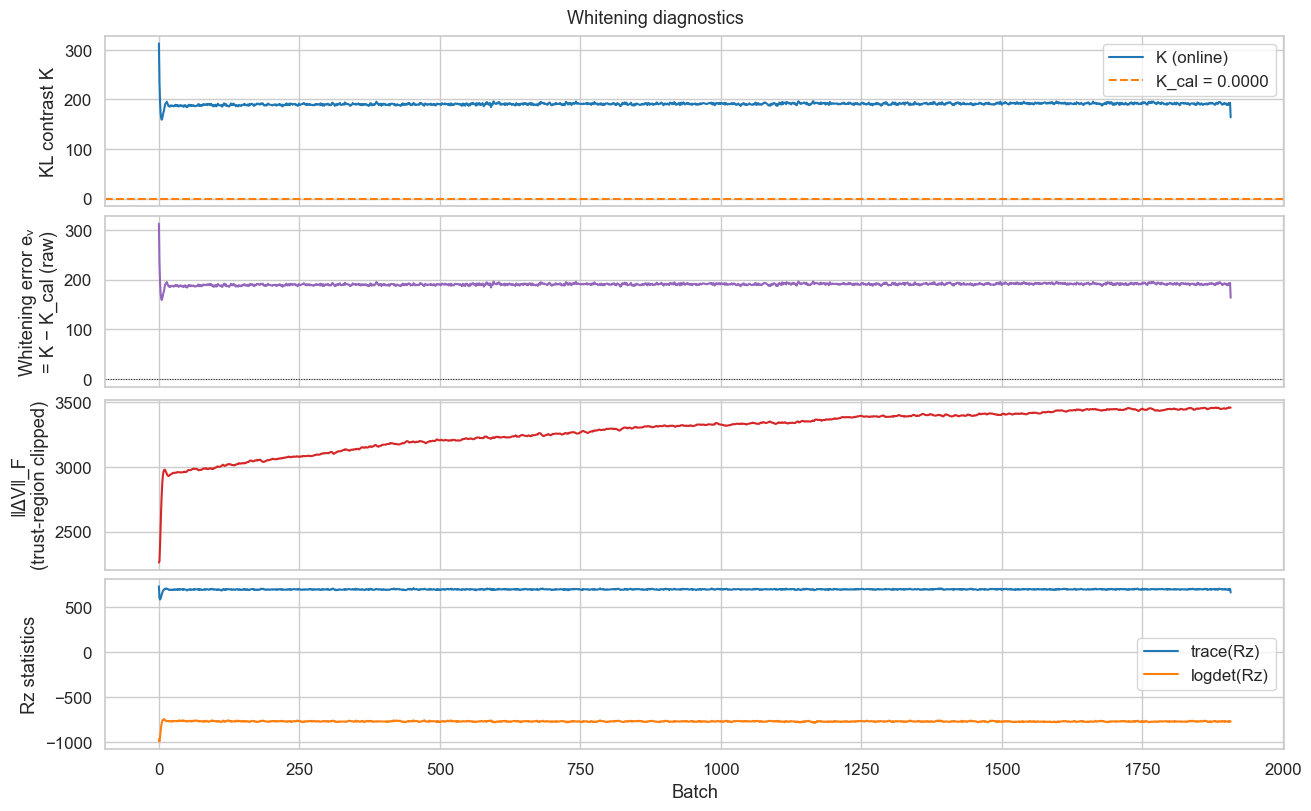

In [38]:
fig, axs = plt.subplots(4, 1, figsize=(13, 8), layout='constrained', sharex=True)

axs[0].plot(batches, K, color='tab:blue', label='K (online)')
axs[0].axhline(K_cal_val, color='tab:orange', linestyle='--',
               label=f'K_cal = {K_cal_val:.4f}')
axs[0].set(ylabel='KL contrast K')
axs[0].legend(loc='upper right')

axs[1].plot(batches, wh_error, color='tab:purple')
axs[1].axhline(0, color='k', linewidth=0.7, linestyle=':')
axs[1].set(ylabel='Whitening error eᵥ\n= K − K_cal (raw)')

axs[2].plot(batches, delta_V_norm, color='tab:red')
axs[2].set(ylabel='‖ΔV‖_F\n(trust-region clipped)')

axs[3].plot(batches, Rz_trace,  color='tab:blue',   label='trace(Rz)')
axs[3].plot(batches, Rz_logdet, color='tab:orange', label='logdet(Rz)')
axs[3].set(ylabel='Rz statistics', xlabel='Batch')
axs[3].legend()

plt.suptitle('Whitening diagnostics', fontsize=13)
plt.show()

### 7.2 Source contrast diagnostics

The separation matrix **B** is updated via a spike-gated natural-gradient step with trust-region clipping:

$$\Delta b_j = -e_{b,j} \cdot \mathbb{E}_{\text{spikes}}[\tanh(y_j)\,z], \qquad \|\Delta b_j\| \leq \texttt{max\_rel\_delta\_b} \times \|b_j\|$$

where $\kappa_j = \overline{\log\cosh(y_j)}$ is the log-cosh contrast and
$e_{b,j} = \kappa_j - \kappa_{\text{cal},j}$ is the raw contrast error.
`tanh` is the exact derivative of `log_cosh` — this gives the natural-gradient direction.
The gradient is computed only from samples marked as spikes; sources with no spikes are not updated.
`max_rel_delta_b` is the sole rate control, acting per B row independently.

**How to read the plots:**
- **κ vs κ_cal** — κ tracks the log-cosh contrast of each source. Persistent deviation from κ_cal
  means the source statistics have changed; the update drives κ back toward κ_cal.
- **Contrast error e_b** — positive = source is more peaky than calibration; negative = flatter.
  Near-zero at calibration; grows when the source drifts. NaN for silent batches (no spikes detected).
- **Spike counts / active** — bars show detected spikes per batch; the red overlay marks batches
  where the source was actually updated. Zero counts disable the update for that batch.
- **‖Δb_j‖** — the per-row trust-region-clipped update magnitude. Proportional to e_b when small;
  pinned at `max_rel_delta_b × ‖b_j‖` when large.
- **‖BB^T − I‖_F** — orthogonality residual after QR. Should be near zero throughout.

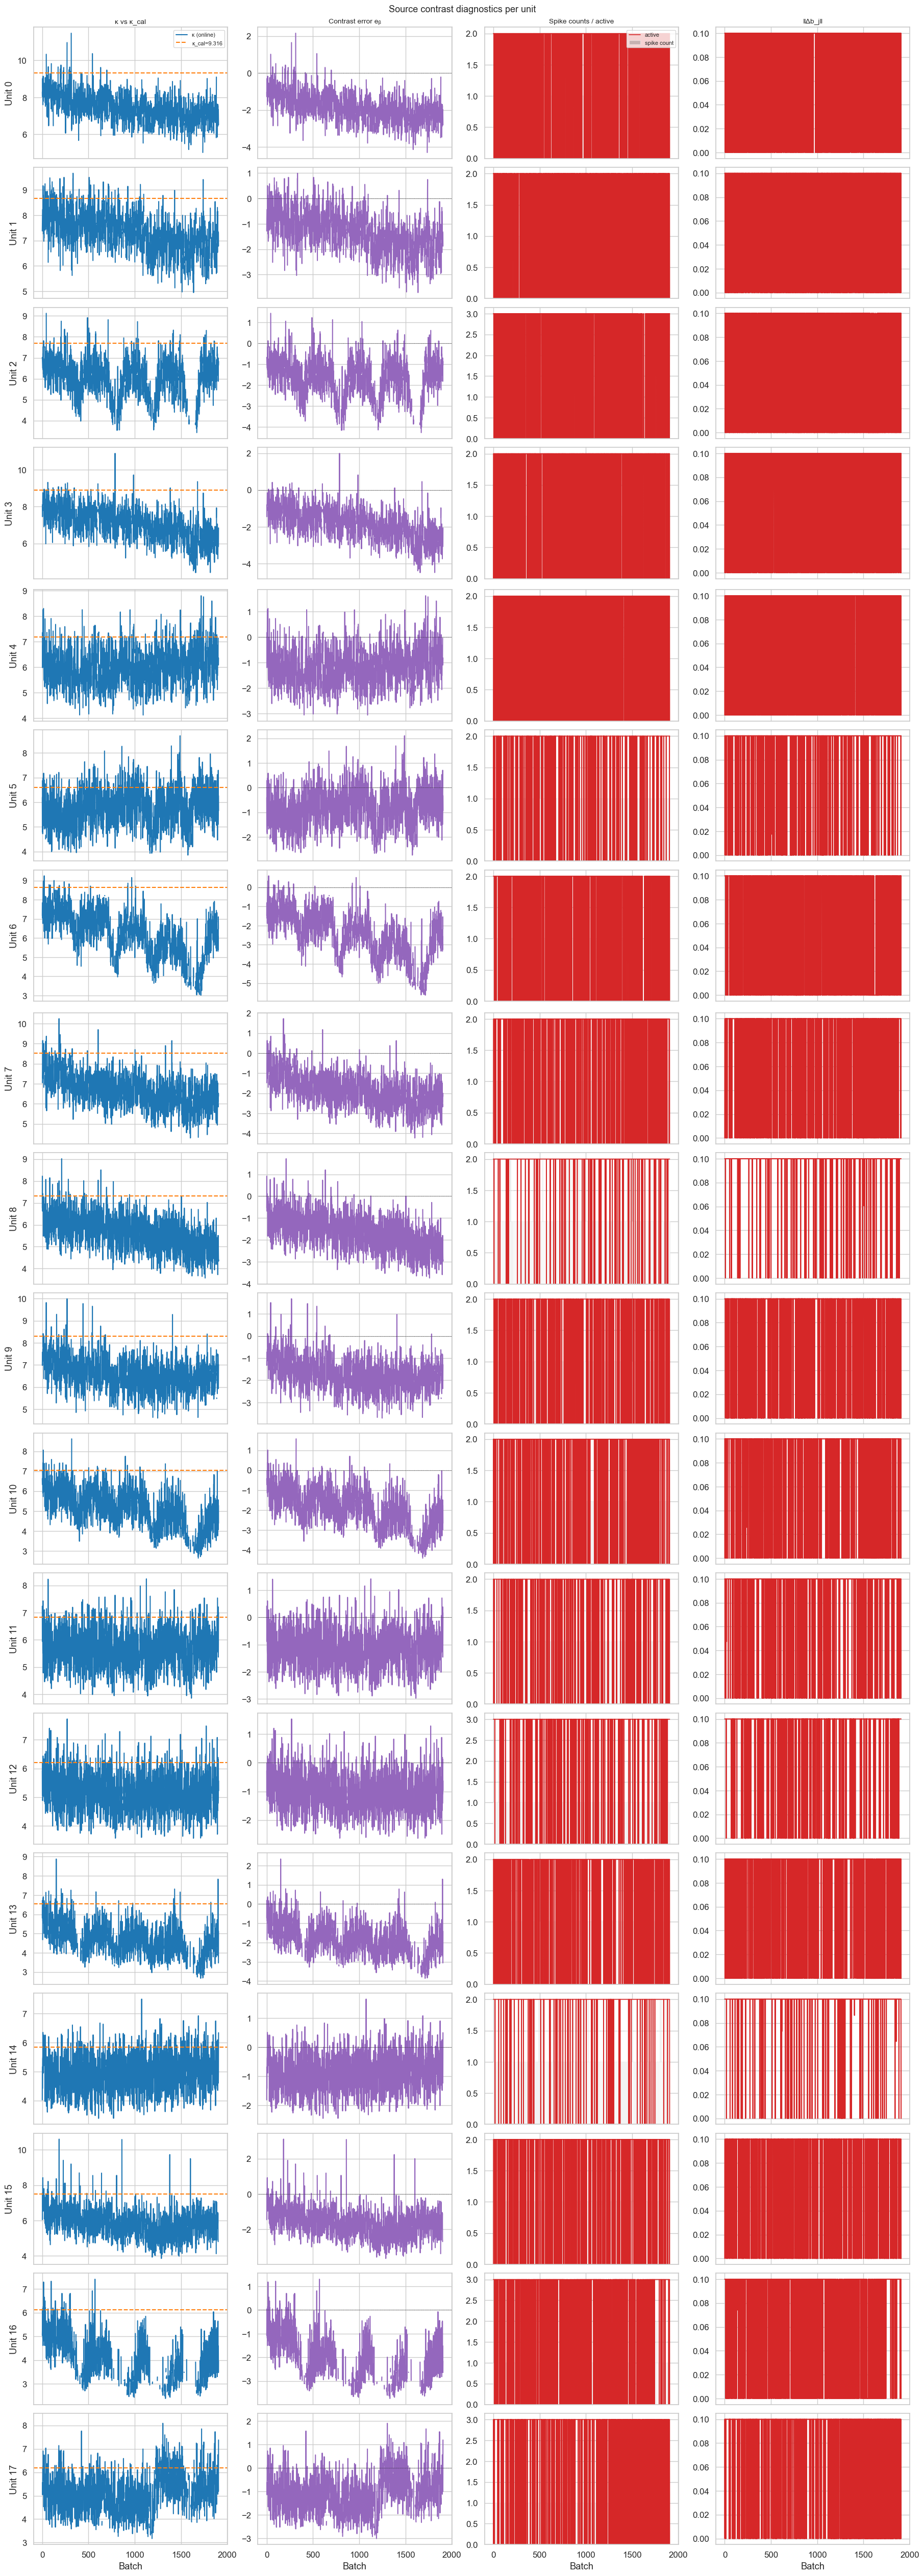

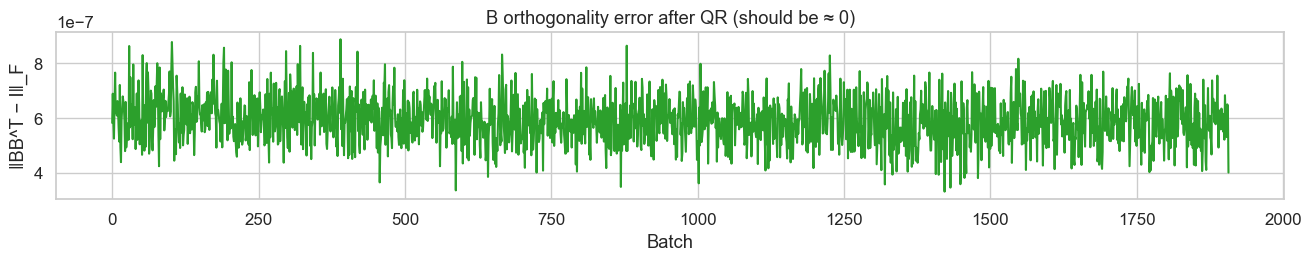

In [39]:
fig, axs = plt.subplots(n_units, 4, figsize=(18, 2.8 * n_units),
                         layout='constrained', sharex=True)
if n_units == 1:
    axs = axs[np.newaxis, :]

col_labels = ['κ vs κ_cal', 'Contrast error eᵦ', 'Spike counts / active', '‖Δb_j‖']
for col, label in enumerate(col_labels):
    axs[0, col].set_title(label, fontsize=10)

for u in range(n_units):
    axs[u, 0].plot(batches, kappa[:, u], color='tab:blue', label='κ (online)')
    axs[u, 0].axhline(kappa_cal_arr[u], color='tab:orange', linestyle='--',
                      label=f'κ_cal={kappa_cal_arr[u]:.3f}')
    axs[u, 0].set(ylabel=f'Unit {u}')
    if u == 0:
        axs[u, 0].legend(loc='upper right', fontsize=8)

    axs[u, 1].plot(batches, contrast_error[:, u], color='tab:purple')
    axs[u, 1].axhline(0, color='k', linewidth=0.7, linestyle=':')

    max_count = max(spike_counts[:, u].max(), 1)
    axs[u, 2].bar(batches, spike_counts[:, u], alpha=0.4, color='tab:grey', label='spike count')
    axs[u, 2].plot(batches, active[:, u] * max_count,
                   color='tab:red', linewidth=1.2, label='active')
    if u == 0:
        axs[u, 2].legend(loc='upper right', fontsize=8)

    axs[u, 3].plot(batches, delta_B_norm[:, u], color='tab:red')

for col in range(4):
    axs[-1, col].set(xlabel='Batch')

plt.suptitle('Source contrast diagnostics per unit', fontsize=13)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(13, 2.5), layout='constrained')
ax.plot(batches, orth_error, color='tab:green')
ax.set(xlabel='Batch', ylabel='‖BB^T − I‖_F',
       title='B orthogonality error after QR (should be ≈ 0)')
plt.show()


### 7.3 Centroid evolution

Spike classification uses an adaptive threshold that tracks the signal:

$$\text{threshold}_j = \text{base\_centroid}_j + 0.5\;(\text{spike\_centroid}_j - \text{base\_centroid}_j)$$

Centroids are initialised from the frozen calibration values and then updated via EMA:

$$\text{spike\_centroid}_j \leftarrow m\,\text{spike\_centroid}_j + (1-m)\,\overline{|y_j|^p}_{\text{accepted spikes}}$$

The invariant `spike_centroid > base_centroid` is enforced: any update that violates it is reverted.
The **calibration centroids** (`_cal`) are immutable — used only for initialisation and diagnostic comparison,
never modified during online operation.

**How to read the plots:**
- Solid lines = adaptive online values (what the detector actually uses).
- Dashed lines = frozen calibration references (starting point and sanity check).
- Slow, smooth drift in the online values is expected and healthy as the signal evolves.
- Sudden jumps or collapse toward zero indicate a detection problem (threshold collapse or artefact burst).
- **Centroid drift** — mean |spike_centroid − spike_centroid_cal| across units.
  Grows predictably with true signal change; rapid growth suggests instability.


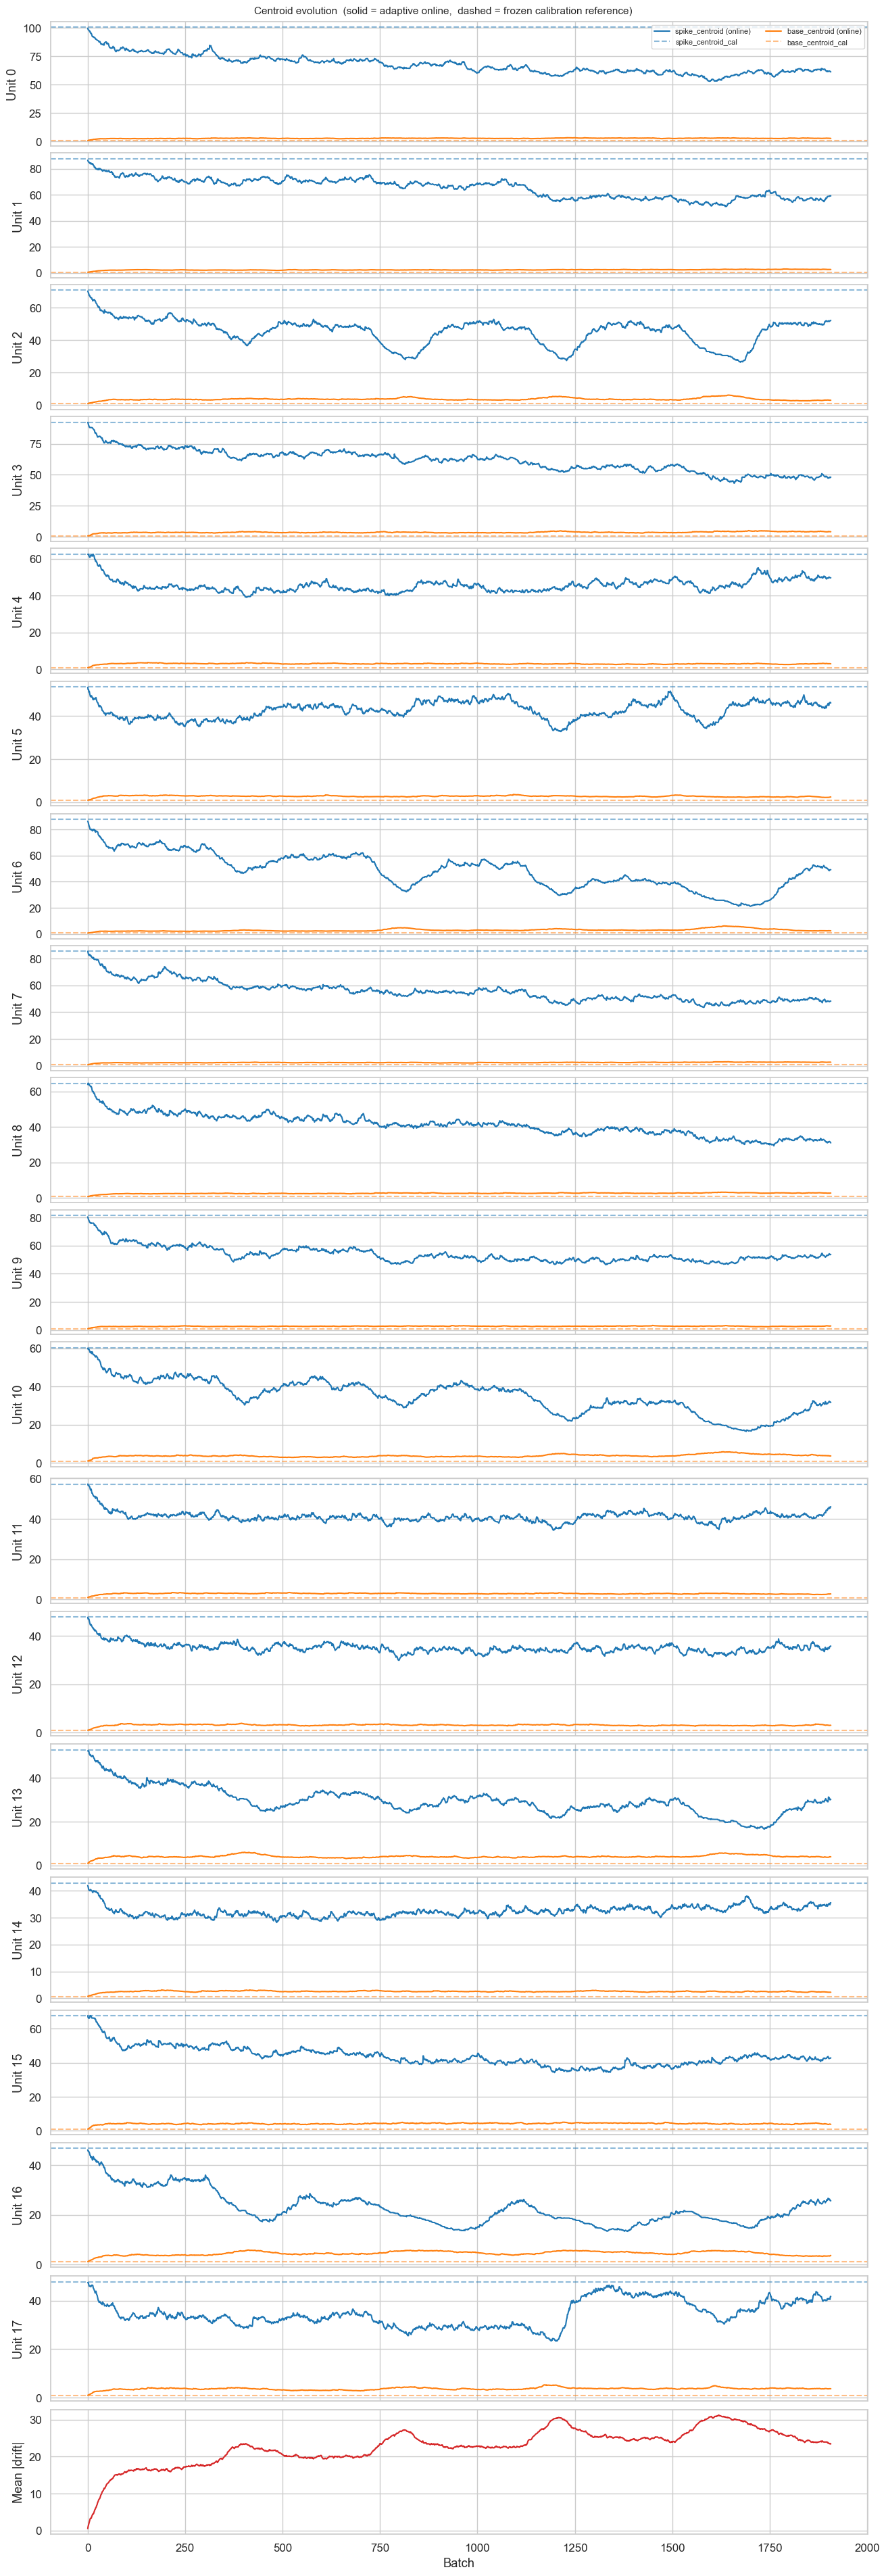

In [40]:
fig, axs = plt.subplots(n_units + 1, 1, figsize=(13, 2 * (n_units + 1)),
                         layout='constrained', sharex=True)

for u in range(n_units):
    axs[u].plot(batches, spike_centroid[:, u], color='tab:blue',
               label='spike_centroid (online)')
    axs[u].axhline(spike_centroid_cal_arr[u], color='tab:blue', linestyle='--', alpha=0.5,
                  label='spike_centroid_cal')
    axs[u].plot(batches, base_centroid[:, u], color='tab:orange',
               label='base_centroid (online)')
    axs[u].axhline(base_centroid_cal_arr[u], color='tab:orange', linestyle='--', alpha=0.5,
                  label='base_centroid_cal')
    axs[u].set(ylabel=f'Unit {u}')
    if u == 0:
        axs[u].legend(loc='upper right', fontsize=8, ncol=2)

axs[-1].plot(batches, centroid_drift, color='tab:red')
axs[-1].set(xlabel='Batch', ylabel='Mean |drift|')

plt.suptitle(
    'Centroid evolution  (solid = adaptive online,  dashed = frozen calibration reference)',
    fontsize=11)
plt.show()


### 7.4 Peak detection throughput

Spike detection runs on the concatenation of the source FIFO (previous batches) and the current batch **Y**
using 1-D max-pool NMS (strict local maxima + minimum-distance window).
Only the current-batch slice of the resulting mask feeds into outputs and adaptation.

- **`peak_counts_before`** — NMS candidate peaks before centroid threshold classification.
- **`peak_counts_after`** — Accepted spikes (candidate AND above the adaptive threshold).

The ratio `after / before` reflects centroid quality:
a ratio near 1 means most candidates are accepted (threshold is low — possibly too low);
a ratio near 0 means almost all candidates are rejected (threshold is high or signal is very weak).


In [41]:
flag = False
if flag:
    fig, axs = plt.subplots(n_units, 1, figsize=(13, 2* n_units),
                            layout='constrained', sharex=True)
    if n_units == 1:
        axs = [axs]

    for u in range(n_units):
        axs[u].bar(batches, peaks_before[:, u], alpha=0.35, color='tab:grey',
                label='NMS candidates')
        axs[u].bar(batches, peaks_after[:, u],  alpha=0.85, color='tab:blue',
                label='Accepted spikes')
        axs[u].set(ylabel=f'Count  –  Unit {u}')
        if u == 0:
            axs[u].legend(loc='upper right', fontsize=8)

    axs[-1].set(xlabel='Batch')
    plt.suptitle('Peak detection throughput per unit', fontsize=13)
    plt.show()
